# Customer Segmentation — RFM + K-Means

**Phase 3 of 4.** Groups the 292 customers into actionable segments using classic RFM (Recency, Frequency, Monetary) feature engineering and K-Means clustering.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

NAVY, TEAL, AMBER, GREY = "#1F3040", "#1B8A85", "#E8AC1F", "#9AA5B1"
PALETTE = [TEAL, AMBER, NAVY, GREY]
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

def money_axis(ax, axis="y"):
    fmt = mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if abs(x) >= 1e6 else f"${x/1e3:.0f}K")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

## 1. Build RFM Features

In [1]:
sales = pd.read_csv("../data/processed/ecommerce_sales_cleaned.csv", parse_dates=["order_date"])
customers = pd.read_csv("../data/processed/customer_summary.csv", parse_dates=["first_order_date", "last_order_date"])

# Snapshot date = one day after the last order in the dataset
snapshot_date = sales["order_date"].max() + pd.Timedelta(days=1)
customers["recency_days"] = (snapshot_date - customers["last_order_date"]).dt.days

rfm = customers[["customer_id", "recency_days", "total_orders", "lifetime_spend"]].copy()
rfm.columns = ["customer_id", "Recency", "Frequency", "Monetary"]
print(f"Snapshot date: {snapshot_date.date()}")
rfm[["Recency","Frequency","Monetary"]].describe().round(1)

Snapshot date: 2024-01-04


## 2. Choosing K — Elbow Method + Silhouette Score

Silhouette score is checked across k=2 through k=8, alongside the elbow method, before committing to a final cluster count.

k=2 | inertia=537.5 | silhouette=0.354
k=3 | inertia=373.1 | silhouette=0.350
k=4 | inertia=296.8 | silhouette=0.337
k=5 | inertia=254.9 | silhouette=0.320
k=6 | inertia=217.1 | silhouette=0.315
k=7 | inertia=187.4 | silhouette=0.304
k=8 | inertia=166.3 | silhouette=0.312


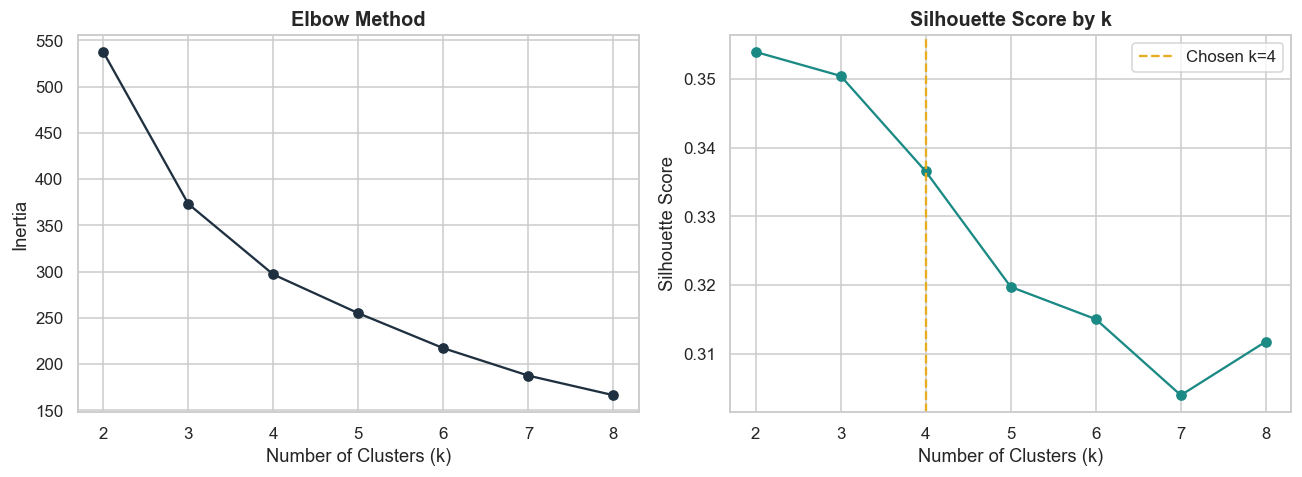

In [1]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency","Frequency","Monetary"]])

k_range = range(2, 9)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

N_CLUSTERS = 4
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", color=NAVY); axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k")
axes[1].plot(list(k_range), sil_scores, marker="o", color=TEAL); axes[1].axvline(N_CLUSTERS, color=AMBER, linestyle="--", label=f"Chosen k={N_CLUSTERS}")
axes[1].set_title("Silhouette Score by k"); axes[1].set_xlabel("k"); axes[1].legend()
plt.tight_layout(); plt.show()

for k, i, s in zip(k_range, inertias, sil_scores):
    print(f"k={k} | inertia={i:.1f} | silhouette={s:.3f}")

**A deliberate judgment call:** silhouette score technically peaks at k=2-3, but k=4 is used here instead. The reason: k=4 is the smallest cluster count that separates out a distinct 14-customer high-value segment (avg. spend $18,540) from the next tier down (avg. spend $6,673) — more than double. That's a genuinely actionable business distinction that k=2/3 would hide, and the statistical cost of choosing k=4 is small (0.337 vs 0.354 — both comfortably above the 0.3 threshold usually considered "reasonable structure").

## 3. Fit Final Model + Name Segments

In [1]:
N_CLUSTERS = 4
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
rfm["cluster"] = km.fit_predict(rfm_scaled)
sil = silhouette_score(rfm_scaled, rfm["cluster"])

# Rank clusters by mean Monetary value and assign business-meaningful names
# programmatically (not hardcoded indices, since KMeans cluster numbering
# isn't guaranteed stable across reruns/versions).
profile = rfm.groupby("cluster")[["Recency","Frequency","Monetary"]].mean()
ranked = profile.sort_values("Monetary", ascending=False).index.tolist()
segment_names = {ranked[0]: "Champions", ranked[1]: "Loyal Customers", ranked[2]: "Developing Customers", ranked[3]: "At Risk / Lost"}
rfm["segment"] = rfm["cluster"].map(segment_names)

print(f"Final silhouette score: {sil:.3f}\n")
rfm.groupby("segment")[["Recency","Frequency","Monetary"]].agg(["mean","count"]).round(1)

Final silhouette score: 0.337


## 4. Visualize Segments

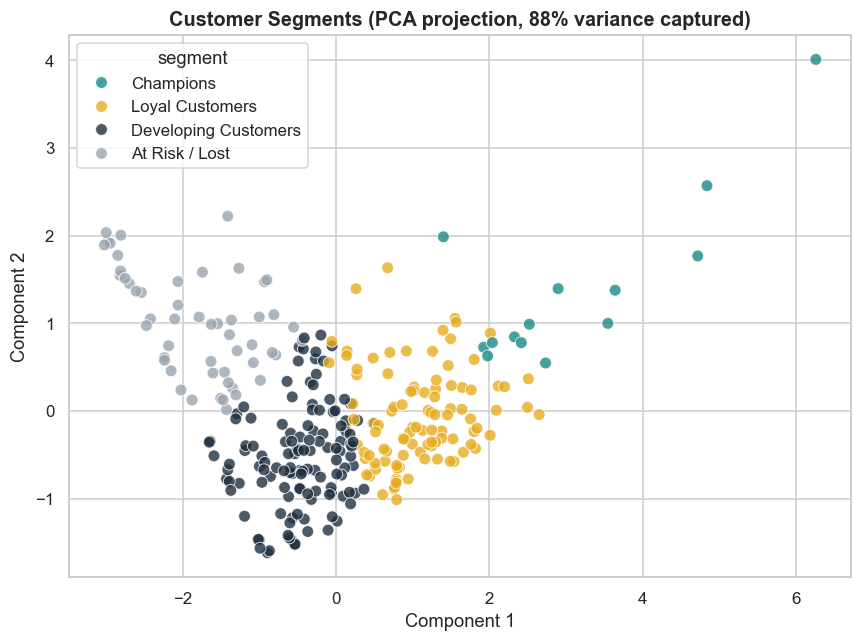

In [1]:
segment_order = ["Champions", "Loyal Customers", "Developing Customers", "At Risk / Lost"]
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(rfm_scaled)
rfm["pca_x"], rfm["pca_y"] = coords[:,0], coords[:,1]

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=rfm, x="pca_x", y="pca_y", hue="segment", hue_order=segment_order, palette=PALETTE, s=60, alpha=0.8, ax=ax)
ax.set_title(f"Customer Segments (PCA, {pca.explained_variance_ratio_.sum()*100:.0f}% variance captured)")
plt.tight_layout(); plt.show()

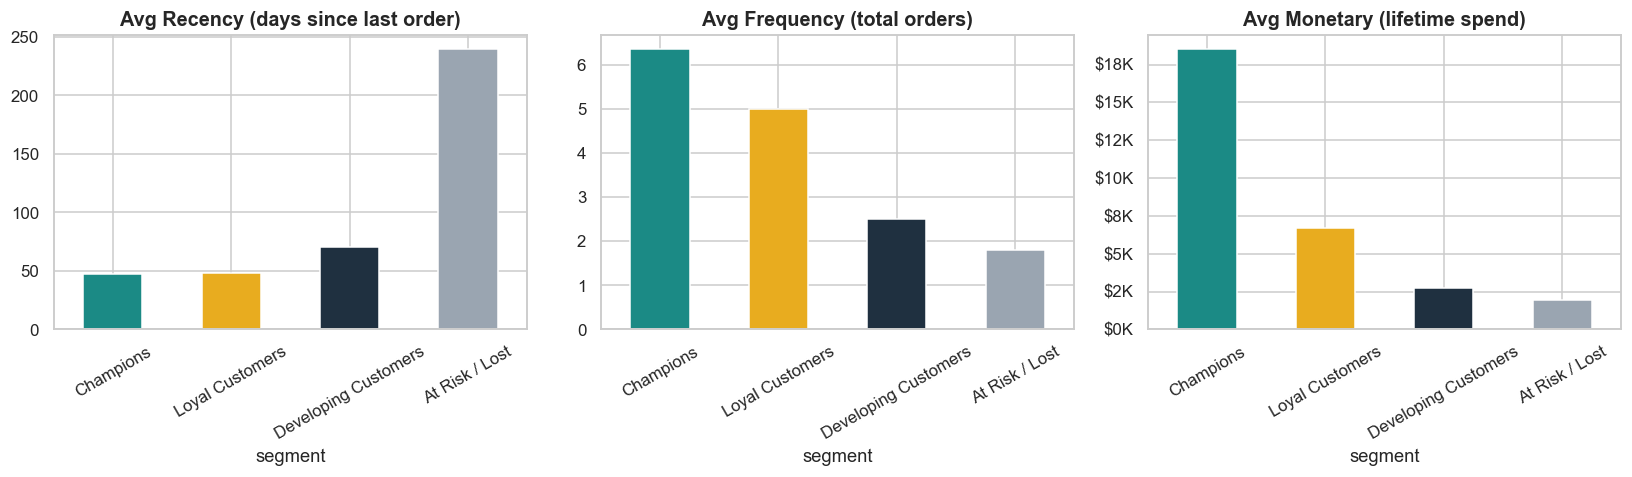

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
means = rfm.groupby("segment")[["Recency","Frequency","Monetary"]].mean().loc[segment_order]
means["Recency"].plot(kind="bar", color=PALETTE, ax=axes[0]); axes[0].set_title("Avg Recency (days)"); axes[0].tick_params(axis="x", rotation=30)
means["Frequency"].plot(kind="bar", color=PALETTE, ax=axes[1]); axes[1].set_title("Avg Frequency (orders)"); axes[1].tick_params(axis="x", rotation=30)
means["Monetary"].plot(kind="bar", color=PALETTE, ax=axes[2]); axes[2].set_title("Avg Monetary (spend)"); money_axis(axes[2]); axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

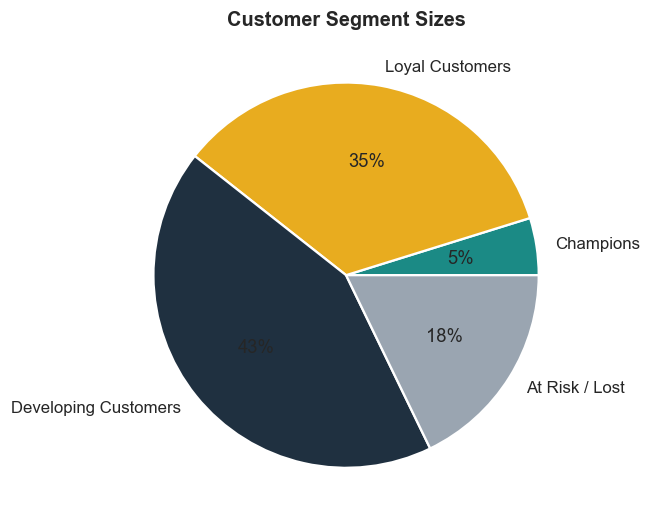

In [1]:
fig, ax = plt.subplots(figsize=(6, 6))
sizes = rfm["segment"].value_counts().loc[segment_order]
ax.pie(sizes, labels=sizes.index, autopct="%1.0f%%", colors=PALETTE, wedgeprops={"edgecolor":"white","linewidth":1.5})
ax.set_title("Customer Segment Sizes")
plt.tight_layout(); plt.show()

Champions               4.8% of customers |  18.8% of revenue
Loyal Customers        34.6% of customers |  48.9% of revenue
Developing Customers   42.8% of customers |  25.0% of revenue
At Risk / Lost         17.8% of customers |   7.3% of revenue


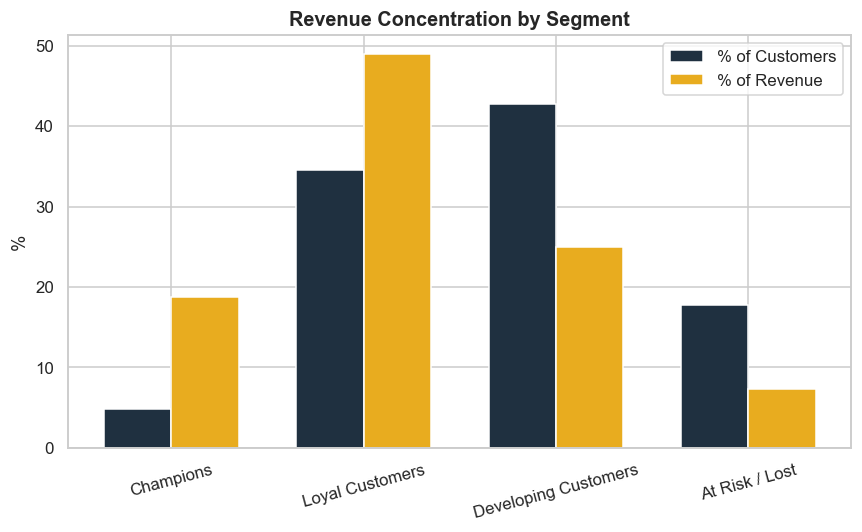

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))
rev_share = rfm.groupby("segment")["Monetary"].sum().loc[segment_order]
rev_pct = (rev_share / rev_share.sum() * 100).round(1)
cust_pct = (rfm["segment"].value_counts().loc[segment_order] / len(rfm) * 100).round(1)
x = np.arange(len(segment_order)); width = 0.35
ax.bar(x - width/2, cust_pct, width, label="% of Customers", color=NAVY)
ax.bar(x + width/2, rev_pct, width, label="% of Revenue", color=AMBER)
ax.set_xticks(x); ax.set_xticklabels(segment_order, rotation=15); ax.set_ylabel("%")
ax.set_title("Revenue Concentration by Segment"); ax.legend()
plt.tight_layout(); plt.show()

for seg in segment_order:
    print(f"{seg:<22} {cust_pct[seg]:5.1f}% of customers | {rev_pct[seg]:5.1f}% of revenue")

## Key Findings

- **Champions** — just 4.8% of customers, but 18.8% of revenue. Averaging $18,540 lifetime spend, ordering frequently, recent activity.
- **Loyal Customers** — the real backbone: 34.6% of customers driving **48.9%** of total revenue.
- **Developing Customers** — the largest group by headcount (42.8%) but only 25% of revenue — the clearest growth opportunity segment.
- **At Risk / Lost** — 17.8% of customers, only 7.3% of revenue, averaging 240 days since last order — a real churn signal worth acting on.

Enriched customer table with segment labels exported to `../data/processed/customer_summary_segmented.csv`.

**Next:** `03_classification_models.ipynb` — comparing scikit-learn and TensorFlow classifiers.